<a href="https://colab.research.google.com/github/Ecesu893/Tasarim2/blob/main/Efficient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, precision_score,
                              recall_score, f1_score)
import numpy as np
import shutil, os, json, zipfile
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from google.colab import files
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🖥️  Kullanılan cihaz:", device)

🖥️  Kullanılan cihaz: cpu


In [ ]:
DATA_DIR = "/content/dataset_4class"
os.makedirs(DATA_DIR, exist_ok=True)

CLASSES = ["Disease-Downy", "Disease-Powdery", "Healthy", "Insect-Pest"]

for folder in CLASSES:
    src = f"/content/{folder}"
    dst = f"{DATA_DIR}/{folder}"
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copytree(src, dst)
        print(f"  ✅ {folder:<22} → {len(os.listdir(dst))} resim")
    elif os.path.exists(dst):
        print(f"  ⚠️  {folder:<22} → {len(os.listdir(dst))} resim (zaten var)")
    else:
        print(f"  ❌ {folder} BULUNAMADI!")

print("\n📊 Sınıf Dağılımı:")
total = 0
for cls in CLASSES:
    p = os.path.join(DATA_DIR, cls)
    if os.path.exists(p):
        n = len([f for f in os.listdir(p)
                 if f.lower().endswith(('.png','.jpg','.jpeg','.bmp','.tiff'))])
        print(f"  {cls:<22}: {n} resim")
        total += n
print(f"  {'TOPLAM':<22}: {total} resim")

  ✅ Disease-Downy          → 166 resim
  ✅ Disease-Powdery        → 105 resim
  ✅ Healthy                → 528 resim
  ✅ Insect-Pest            → 250 resim

📊 Sınıf Dağılımı:
  Disease-Downy         : 166 resim
  Disease-Powdery       : 105 resim
  Healthy               : 528 resim
  Insect-Pest           : 250 resim
  TOPLAM                : 1049 resim


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

dataset    = datasets.ImageFolder(root=DATA_DIR, transform=transform)
CLASS_NAMES = dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"📂 Sınıflar : {CLASS_NAMES}")
print(f"📊 Toplam   : {len(dataset)}")

# Stratified split — her sınıftan orantılı örnek
all_indices  = list(range(len(dataset)))
all_labels   = [dataset.samples[i][1] for i in all_indices]

train_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.3,
    random_state=42,
    stratify=all_labels
)

train_set = Subset(dataset, train_indices)
test_set  = Subset(dataset, test_indices)

# WeightedRandomSampler — sınıf dengesizliğini gider
train_labels  = [all_labels[i] for i in train_indices]
class_counts  = Counter(train_labels)
weights       = [1.0 / class_counts[all_labels[i]] for i in train_indices]
sampler       = WeightedRandomSampler(weights, len(weights), replacement=True)

train_loader = DataLoader(train_set, batch_size=16, sampler=sampler)
test_loader  = DataLoader(test_set,  batch_size=16, shuffle=False)

print(f"\n✅ Train: {len(train_indices)} | Test: {len(test_indices)}")

print("\nTrain sınıf dağılımı:")
train_counts = Counter(train_labels)
for idx, cname in enumerate(CLASS_NAMES):
    print(f"  {cname:<22}: {train_counts[idx]}")

print("\nTest sınıf dağılımı:")
test_labels  = [all_labels[i] for i in test_indices]
test_counts  = Counter(test_labels)
for idx, cname in enumerate(CLASS_NAMES):
    print(f"  {cname:<22}: {test_counts[idx]}")

📂 Sınıflar : ['Disease-Downy', 'Disease-Powdery', 'Healthy', 'Insect-Pest']
📊 Toplam   : 1049

✅ Train: 734 | Test: 315

Train sınıf dağılımı:
  Disease-Downy         : 116
  Disease-Powdery       : 74
  Healthy               : 369
  Insect-Pest           : 175

Test sınıf dağılımı:
  Disease-Downy         : 50
  Disease-Powdery       : 31
  Healthy               : 159
  Insect-Pest           : 75


In [ ]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

EPOCHS  = 15
history = {'loss': [], 'acc': []}

print("🚀 EfficientNet-B0 [NoAug] eğitimi başlıyor...\n")

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0, 0, 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = torch.max(outputs.data, 1)
        total         += labels.size(0)
        correct       += (predicted == labels).sum().item()

        if (batch_idx + 1) % 10 == 0:
            print(f"  Epoch [{epoch+1}/{EPOCHS}] "
                  f"Batch [{batch_idx+1}/{len(train_loader)}] "
                  f"Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(train_loader)
    epoch_acc  = 100 * correct / total
    history['loss'].append(epoch_loss)
    history['acc'].append(epoch_acc)
    scheduler.step()
    print(f"✅ Epoch {epoch+1}/{EPOCHS} — Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%")

print("\n🎉 Eğitim tamamlandı!")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 141MB/s]


🚀 EfficientNet-B0 [NoAug] eğitimi başlıyor...

  Epoch [1/15] Batch [10/46] Loss: 1.3682
  Epoch [1/15] Batch [20/46] Loss: 1.2240
  Epoch [1/15] Batch [30/46] Loss: 1.1364
  Epoch [1/15] Batch [40/46] Loss: 1.0789
✅ Epoch 1/15 — Loss: 1.2089, Acc: 50.00%
  Epoch [2/15] Batch [10/46] Loss: 0.8944
  Epoch [2/15] Batch [20/46] Loss: 0.9858
  Epoch [2/15] Batch [30/46] Loss: 0.8871
  Epoch [2/15] Batch [40/46] Loss: 0.7657
✅ Epoch 2/15 — Loss: 0.8718, Acc: 73.71%
  Epoch [3/15] Batch [10/46] Loss: 0.7773
  Epoch [3/15] Batch [20/46] Loss: 0.5822
  Epoch [3/15] Batch [30/46] Loss: 0.5182
  Epoch [3/15] Batch [40/46] Loss: 0.4779
✅ Epoch 3/15 — Loss: 0.6359, Acc: 80.25%
  Epoch [4/15] Batch [10/46] Loss: 0.3793
  Epoch [4/15] Batch [20/46] Loss: 0.5677
  Epoch [4/15] Batch [30/46] Loss: 0.4888
  Epoch [4/15] Batch [40/46] Loss: 0.3649
✅ Epoch 4/15 — Loss: 0.3875, Acc: 90.74%
  Epoch [5/15] Batch [10/46] Loss: 0.2132
  Epoch [5/15] Batch [20/46] Loss: 0.4927
  Epoch [5/15] Batch [30/46] Loss

In [ ]:
model.eval()
all_preds, all_labels_test = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels_test.extend(labels.cpu().numpy())

accuracy  = accuracy_score(all_labels_test, all_preds)
precision = precision_score(all_labels_test, all_preds, average='weighted', zero_division=0)
recall    = recall_score(all_labels_test, all_preds, average='weighted', zero_division=0)
f1        = f1_score(all_labels_test, all_preds, average='weighted', zero_division=0)
f1_per    = f1_score(all_labels_test, all_preds, average=None,
                     labels=list(range(NUM_CLASSES)), zero_division=0)
cm        = confusion_matrix(all_labels_test, all_preds)

print(f"{'='*60}")
print(f"📊 EfficientNet-B0 [NoAug] Test Sonuçları")
print(f"{'='*60}")
print(f"🎯 Accuracy : {accuracy*100:.2f}%")
print(f"🎯 Precision: {precision*100:.2f}%")
print(f"🎯 Recall   : {recall*100:.2f}%")
print(f"🎯 F1-Score : {f1*100:.2f}%")
print(f"\n📋 Classification Report:")
print(classification_report(all_labels_test, all_preds,
                            target_names=CLASS_NAMES, zero_division=0))
print(f"🔢 Confusion Matrix:\n{cm}")
print(f"{'='*60}")

# Sonuçları kaydet — Notebook 5 için
results = {
    'model'        : 'EfficientNet-B0',
    'augmentation' : False,
    'accuracy'     : accuracy,
    'precision'    : precision,
    'recall'       : recall,
    'f1'           : f1,
    'f1_per_class' : f1_per.tolist(),
    'class_names'  : CLASS_NAMES
}
with open('/content/results_efficientnet_noaug.json', 'w') as f:
    json.dump(results, f)
print("\n💾 results_efficientnet_noaug.json kaydedildi.")

📊 EfficientNet-B0 [NoAug] Test Sonuçları
🎯 Accuracy : 73.65%
🎯 Precision: 72.38%
🎯 Recall   : 73.65%
🎯 F1-Score : 72.65%

📋 Classification Report:
                 precision    recall  f1-score   support

  Disease-Downy       0.62      0.50      0.56        50
Disease-Powdery       0.68      0.81      0.74        31
        Healthy       0.83      0.91      0.87       159
    Insect-Pest       0.59      0.49      0.54        75

       accuracy                           0.74       315
      macro avg       0.68      0.68      0.67       315
   weighted avg       0.72      0.74      0.73       315

🔢 Confusion Matrix:
[[ 25   3   8  14]
 [  1  25   3   2]
 [  2   2 145  10]
 [ 12   7  19  37]]

💾 results_efficientnet_noaug.json kaydedildi.


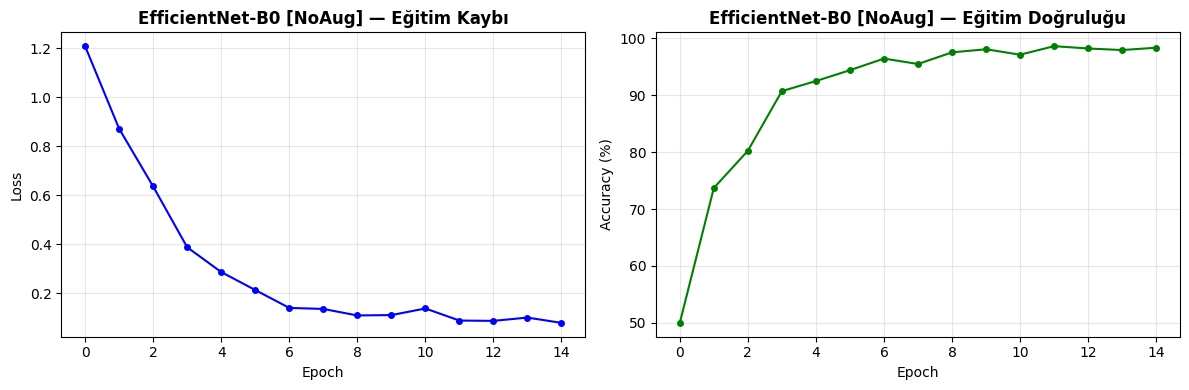

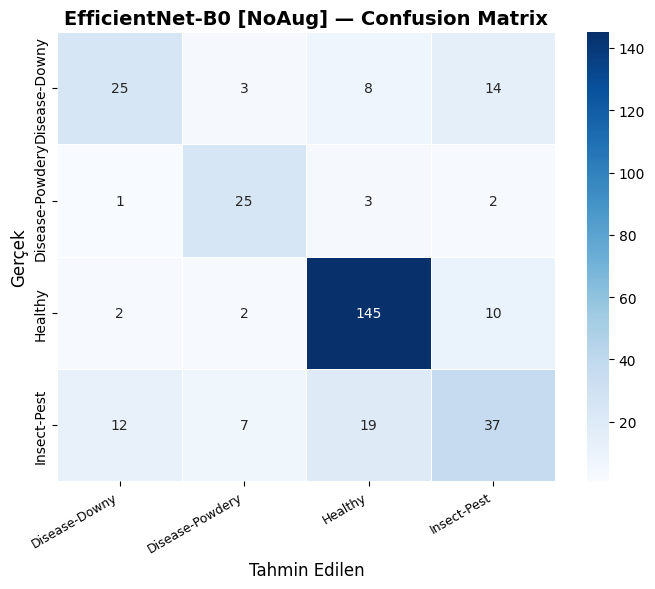

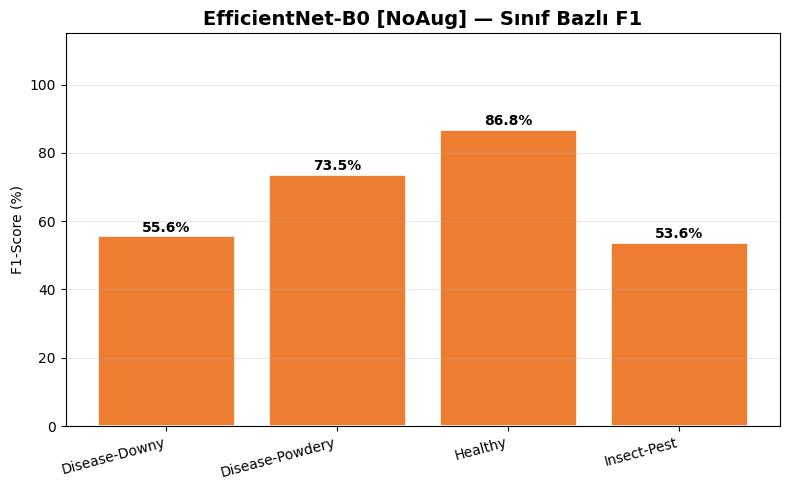

💾 Tüm görseller kaydedildi.


In [ ]:
# ── Eğitim grafiği ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['loss'], 'b-o', markersize=4)
ax1.set_title('EfficientNet-B0 [NoAug] — Eğitim Kaybı', weight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.grid(True, alpha=0.3)
ax2.plot(history['acc'], 'g-o', markersize=4)
ax2.set_title('EfficientNet-B0 [NoAug] — Eğitim Doğruluğu', weight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)'); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/efficientnet_noaug_history.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Confusion Matrix ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Tahmin Edilen', fontsize=12)
ax.set_ylabel('Gerçek', fontsize=12)
ax.set_title('EfficientNet-B0 [NoAug] — Confusion Matrix', fontsize=14, weight='bold')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('/content/efficientnet_noaug_cm.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Sınıf bazlı F1 ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(CLASS_NAMES, f1_per * 100, color='#ED7D31',
              edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, f1_per * 100):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, weight='bold')
ax.set_title('EfficientNet-B0 [NoAug] — Sınıf Bazlı F1', fontsize=14, weight='bold')
ax.set_ylabel('F1-Score (%)')
ax.set_ylim(0, 115)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('/content/efficientnet_noaug_f1.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Tüm görseller kaydedildi.")

In [ ]:
torch.save(model.state_dict(), '/content/efficientnet_noaug.pth')

zip_path = '/content/notebook3_efficientnet_noaug.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in ['/content/efficientnet_noaug_history.png',
              '/content/efficientnet_noaug_cm.png',
              '/content/efficientnet_noaug_f1.png',
              '/content/efficientnet_noaug.pth',
              '/content/results_efficientnet_noaug.json']:
        if os.path.exists(f):
            zf.write(f, os.path.basename(f))

files.download(zip_path)
print("✅ notebook3_efficientnet_noaug.zip indirildi!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ notebook3_efficientnet_noaug.zip indirildi!
